In [6]:
import tifffile
import numpy as np
import matplotlib.pyplot as plt

from skimage.filters import gaussian, median
from skimage.morphology import disk
from skimage.restoration import denoise_nl_means, estimate_sigma

# 1. Read the 4D image data
train_image = tifffile.imread(r'D:\Homework\project\jump\data\22125685f24e39a69900bc5be41548aa-noisy.tiff')
print("Image shape:", train_image.shape)  # (517, 4, 540, 540) expected
print("Data type:", train_image.dtype)


Image shape: (517, 4, 540, 540)
Data type: float32


In [2]:
# 2. Create empty arrays to store denoised results
#    Using float32 to ensure enough precision for intermediate results
gaussian_denoised = np.zeros_like(train_image, dtype=np.float32)
median_denoised   = np.zeros_like(train_image, dtype=np.float32)
nlm_denoised      = np.zeros_like(train_image, dtype=np.float32)

# Get dimensions for loops
num_frames, num_channels, height, width = train_image.shape

In [4]:
# 3. Loop over frames and channels to apply 2D filters
for f in range(num_frames):
    for c in range(num_channels):
        # Extract one 2D slice: shape (540, 540)
        slice_2d = train_image[f, c, :, :]

        # --- Gaussian Filtering ---
        # 'sigma' controls the blur intensity
        # Adjust 'sigma' based on your needs
        g_filtered = gaussian(slice_2d, sigma=1)

        # --- Median Filtering ---
        # Using a 2D footprint disk(3) with radius=3
        m_filtered = median(slice_2d, footprint=disk(3))

        # --- Non-Local Means (NL-Means) ---
        # 1) Estimate noise standard deviation from this slice
        sigma_est = np.mean(estimate_sigma(slice_2d, channel_axis=None))
        # 2) Use denoise_nl_means on this slice
        # 'patch_size', 'patch_distance', and 'h' can be tuned
        nlm_filtered = denoise_nl_means(
            slice_2d,
            patch_size=5,
            patch_distance=6,
            h=1.0 * sigma_est,   # Typically around the estimated sigma
            fast_mode=True,
            preserve_range=True
        )

        # Save the results back into the 4D arrays
        gaussian_denoised[f, c] = g_filtered
        median_denoised[f, c]   = m_filtered
        nlm_denoised[f, c]      = nlm_filtered


Text(0.5, 1.0, 'Channel 4')

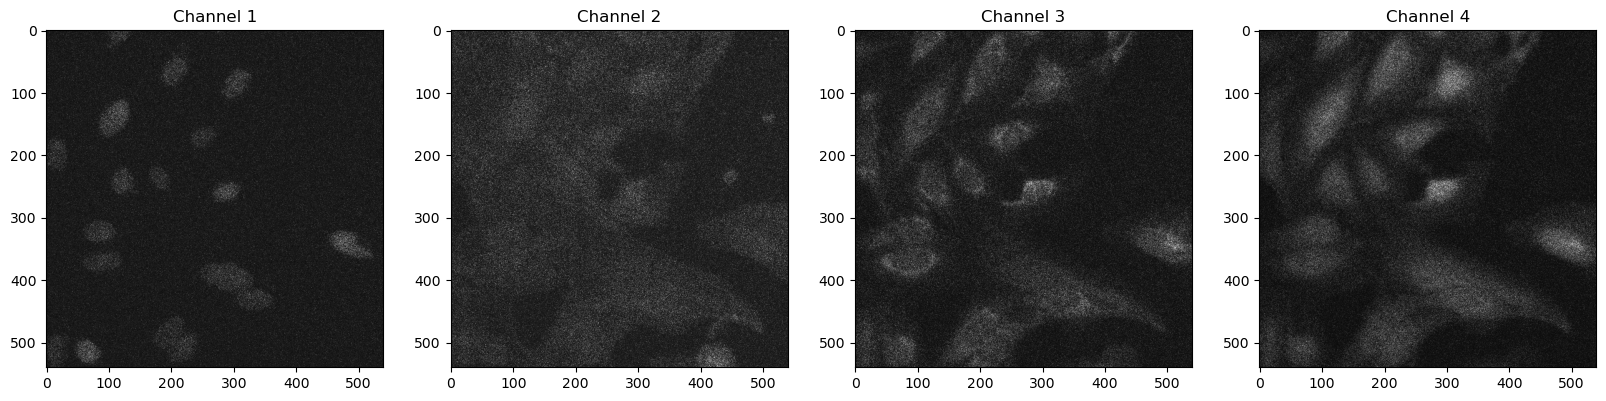

In [5]:
fig, ax = plt.subplots(1, 4, figsize=(20, 5))
ax[0].imshow(train_image[0][0], cmap="gray")
ax[0].set_title("Channel 1")
ax[1].imshow(train_image[0][1], cmap="gray")
ax[1].set_title("Channel 2")
ax[2].imshow(train_image[0][2], cmap="gray")
ax[2].set_title("Channel 3")
ax[3].imshow(train_image[0][3], cmap="gray")
ax[3].set_title("Channel 4")

Text(0.5, 1.0, 'Channel 4')

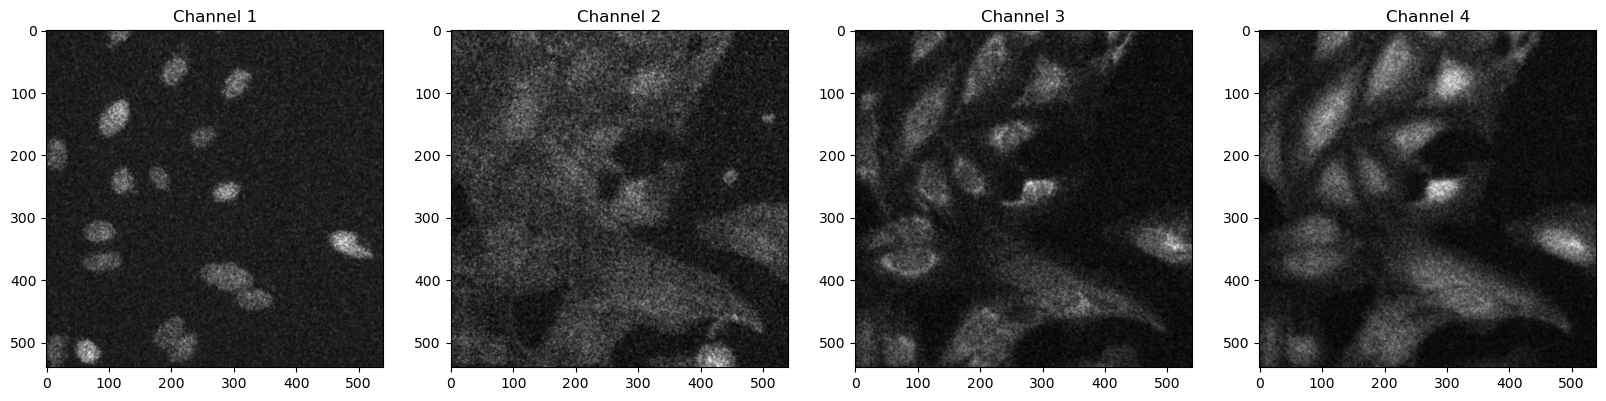

In [6]:
fig, ax = plt.subplots(1, 4, figsize=(20, 5))
plt.title("Gaussian Filtered")
ax[0].imshow(gaussian_denoised[0][0], cmap="gray")
ax[0].set_title("Channel 1")
ax[1].imshow(gaussian_denoised[0][1], cmap="gray")
ax[1].set_title("Channel 2")
ax[2].imshow(gaussian_denoised[0][2], cmap="gray")
ax[2].set_title("Channel 3")
ax[3].imshow(gaussian_denoised[0][3], cmap="gray")
ax[3].set_title("Channel 4")

Text(0.5, 1.0, 'Channel 4')

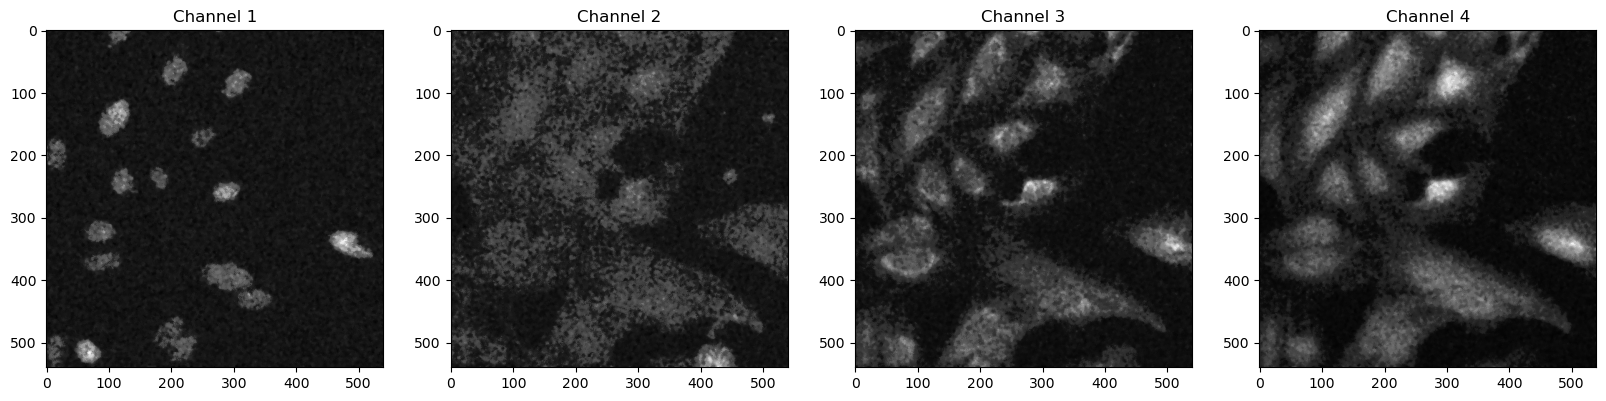

In [7]:
fig, ax = plt.subplots(1, 4, figsize=(20, 5))
plt.title("Median Filtered")
ax[0].imshow(median_denoised[0][0], cmap="gray")
ax[0].set_title("Channel 1")
ax[1].imshow(median_denoised[0][1], cmap="gray")
ax[1].set_title("Channel 2")
ax[2].imshow(median_denoised[0][2], cmap="gray")
ax[2].set_title("Channel 3")
ax[3].imshow(median_denoised[0][3], cmap="gray")
ax[3].set_title("Channel 4")

Text(0.5, 1.0, 'Channel 4')

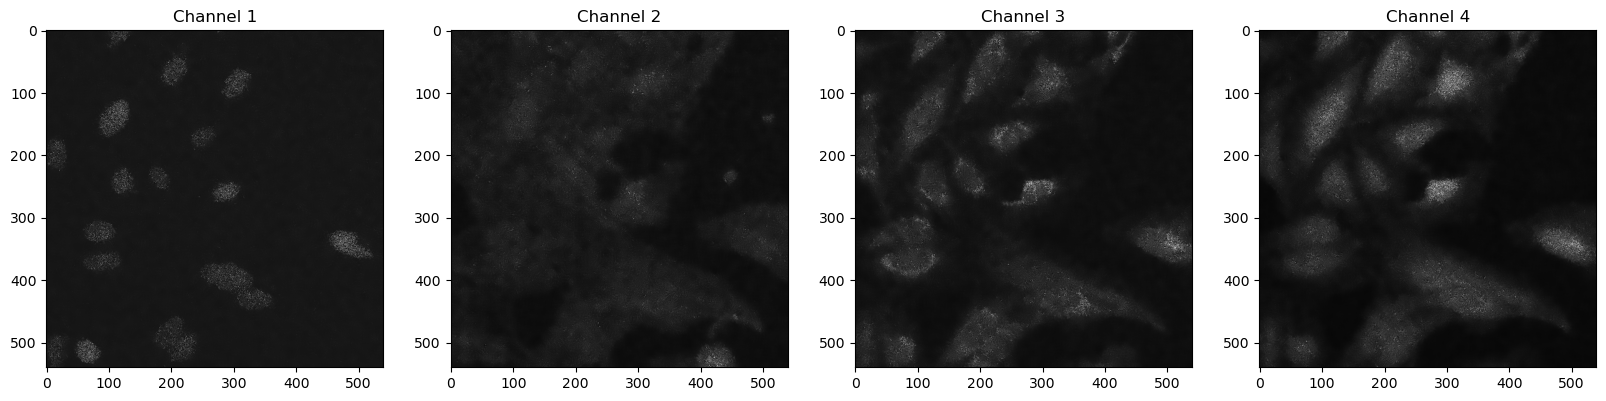

In [8]:
fig, ax = plt.subplots(1, 4, figsize=(20, 5))
plt.title("NL-Means Denoised")
ax[0].imshow(nlm_denoised[0][0], cmap="gray")
ax[0].set_title("Channel 1")
ax[1].imshow(nlm_denoised[0][1], cmap="gray")
ax[1].set_title("Channel 2")
ax[2].imshow(nlm_denoised[0][2], cmap="gray")
ax[2].set_title("Channel 3")
ax[3].imshow(nlm_denoised[0][3], cmap="gray")
ax[3].set_title("Channel 4")

In [10]:
import numpy as np
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
from pytorch_msssim import ms_ssim
import torch


def scale_invariant_psnr(gt, pred, data_range=1.0):
    numerator = np.sum(gt * pred)
    denominator = np.sum(pred ** 2)

    if denominator < 1e-12:
        alpha = 0.0
    else:
        alpha = numerator / denominator

    scaled_pred = alpha * pred
    mse = np.mean((gt - scaled_pred) ** 2)

    if mse < 1e-12:
        return 100.0

    sip = 10 * np.log10((data_range ** 2) / mse)
    return sip


def calculate_metrics(train_image, prediction, data_range=22.0):
    psnr_list = []
    sipsnr_list = []
    ssim_list = []
    msssim_list = []

    N, C, H, W = train_image.shape

    for i in range(N):
        for c in range(C):
            gt = train_image[i, c]            # shape: (H, W)
            pred = prediction[i, c]          # shape: (H, W)

            p = peak_signal_noise_ratio(gt, pred, data_range=data_range)
            psnr_list.append(p)

            sp = scale_invariant_psnr(gt, pred, data_range=data_range)
            sipsnr_list.append(sp)

            s = structural_similarity(gt, pred, data_range=data_range)
            ssim_list.append(s)

            gt_ms = np.expand_dims(gt, axis=0)  # shape: (1, H, W)
            gt_ms = torch.tensor(np.expand_dims(gt_ms, axis=0))
            pred_ms = np.expand_dims(pred, axis=0)  # shape: (1, H, W)
            pred_ms = torch.tensor(np.expand_dims(pred_ms, axis=0))
            
            ms = ms_ssim(gt_ms, pred_ms, data_range=data_range)
            msssim_list.append(ms)

    metrics = {
        'PSNR':     np.mean(psnr_list),
        'SIPSNR':   np.mean(sipsnr_list),
        'SSIM':     np.mean(ssim_list),
        'MS-SSIM':  np.mean(msssim_list),
    }
    return metrics



gt_image = tifffile.imread(r'D:\Homework\project\jump\gt\jump2.tif')
metrics_dict = calculate_metrics(gt_image, gaussian_denoised, data_range=22.0)
print("PSNR:   ", metrics_dict['PSNR'])
print("SIPSNR: ", metrics_dict['SIPSNR'])
print("SSIM:   ", metrics_dict['SSIM'])
print("MS-SSIM:", metrics_dict['MS-SSIM'])


PSNR:    40.816396388683444
SIPSNR:  41.39487700356548
SSIM:    0.9102795240336996
MS-SSIM: 0.9697723


In [11]:
metrics_dict = calculate_metrics(gt_image, median_denoised, data_range=22.0)
print("PSNR:   ", metrics_dict['PSNR'])
print("SIPSNR: ", metrics_dict['SIPSNR'])
print("SSIM:   ", metrics_dict['SSIM'])
print("MS-SSIM:", metrics_dict['MS-SSIM'])

PSNR:    40.759735034961956
SIPSNR:  40.91429693687481
SSIM:    0.8451491955140433
MS-SSIM: 0.97077316


In [12]:
metrics_dict = calculate_metrics(gt_image, nlm_denoised, data_range=22.0)
print("PSNR:   ", metrics_dict['PSNR'])
print("SIPSNR: ", metrics_dict['SIPSNR'])
print("SSIM:   ", metrics_dict['SSIM'])
print("MS-SSIM:", metrics_dict['MS-SSIM'])

PSNR:    36.72789264870398
SIPSNR:  37.70153274423513
SSIM:    0.9086618739544224
MS-SSIM: 0.98142207
